WITHOUT FUZZY

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# =====================
# Load Dataset
# =====================
df = pd.read_csv("/content/Banglore_traffic_Dataset.csv")

# Drop non-numeric columns except target ones
non_numeric = df.select_dtypes(include=['object']).columns
df = df.drop(non_numeric, axis=1, errors="ignore")

# Fill missing values
df = df.ffill()

# =====================
# Helper: Create Sequences
# =====================
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

# =====================
# 1) Travel Time Index - Regression
# =====================
if "Travel Time Index" in df.columns:
    features = df.drop(["Travel Time Index"], axis=1, errors="ignore")
    target = df["Travel Time Index"]

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(features.values)

    X_seq, y_seq = create_sequences(X_scaled, target.values)

    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)

    model = Sequential([
        LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
        Dropout(0.3),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

    y_pred = model.predict(X_test)

    print("\n🔹 Travel Time Index (Regression):")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R²:", r2_score(y_test, y_pred))

# =====================
# 2) Traffic Volume - Regression
# =====================
if "Traffic Volume" in df.columns:
    features = df.drop(["Traffic Volume"], axis=1, errors="ignore")
    target = df["Traffic Volume"]

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(features.values)

    X_seq, y_seq = create_sequences(X_scaled, target.values)

    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)

    model = Sequential([
        LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
        Dropout(0.3),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

    y_pred = model.predict(X_test)

    print("\n🔹 Traffic Volume (Regression):")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R²:", r2_score(y_test, y_pred))






Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


224/224 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.3778
Epoch 2/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0570
Epoch 3/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0528
Epoch 4/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0494
Epoch 5/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0508
Epoch 6/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0468
Epoch 7/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0465
Epoch 8/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0482
Epoch 9/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0446
Epoch 10/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0440
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

🔹 Travel Time Index (Regression):
MSE: 0.027488898091608257
RMSE: 0.16579776262545962
MAE: 0.14905628757595654
R²: -0.022417066134769792
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 636454400.0000
Epoch 2/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 193820496.0000
Epoch 3/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 190475600.0000
Epoch 4/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 185147408.0000
Epoch 5/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 189897568.0000
Epoch 6/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 186918944.0000
Epoch 7/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 185453520.0000
Epoch 8/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 189538736.0000
Epoch 9/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 189444032.0000
Epoch 10/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 186859744.0000
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

🔹 Traffic Volume (Regression):
MSE: 167220352.0
RMSE: 12931.370847671178
MAE: 10607.30859375
R²: -0.013898134231567383


In [ ]:
# =====================
# 3) Congestion Level - Classification (Always Low/Medium/High)
# =====================
if "Congestion Level" in df.columns:
    # Force 3 bins between min and max values
    df["Congestion_Class"] = pd.cut(
        df["Congestion Level"],
        bins=3,
        labels=["Low", "Medium", "High"],
        include_lowest=True
    )

    features = df.drop(
        ["Travel Time Index", "Congestion Level", "Traffic Volume", "Congestion_Class"],
        axis=1, errors="ignore"
    )
    target = df["Congestion_Class"]

    le = LabelEncoder()
    y_encoded = le.fit_transform(target)

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(features.values)

    X_seq, y_seq = create_sequences(X_scaled, y_encoded)

    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)

    # Build deeper LSTM model
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(len(le.classes_), activation='softmax')
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Early stopping
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        callbacks=[es],
        verbose=1
    )

    # Predictions
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print("\n🔹 Congestion Level (Classification):")
    print("Classes:", list(le.classes_))  # Should always show ['Low', 'Medium', 'High']
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


179/179 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.6996 - loss: 0.8165 - val_accuracy: 0.7157 - val_loss: 0.7524
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7185 - loss: 0.7660 - val_accuracy: 0.7157 - val_loss: 0.7515
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7231 - loss: 0.7567 - val_accuracy: 0.7157 - val_loss: 0.7516
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7274 - loss: 0.7479 - val_accuracy: 0.7157 - val_loss: 0.7547
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.7222 - loss: 0.7538 - val_accuracy: 0.7157 - val_loss: 0.7509
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.7251 - loss: 0.7439 - val_accuracy: 0.7157 - val_loss: 0.7515
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.7247 - loss: 0.7515 - val_accuracy: 0.7157 - val_loss: 0.7511
Epoch 8/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7222 - loss: 0.7495 - val_accuracy: 0.71

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


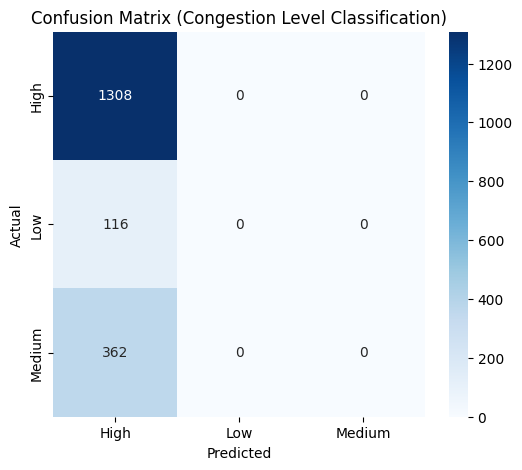

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Your confusion matrix
cm = np.array([
    [1308, 0, 0],
    [116, 0, 0],
    [362, 0, 0]
])

# Class labels
labels = ['High', 'Low', 'Medium']

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Congestion Level Classification)")
plt.show()


WITH FUZZY

In [ ]:
pip install scikit-fuzzy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 14.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import skfuzzy as fuzz
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# =====================
# Load Dataset
# =====================
df = pd.read_csv("/content/Banglore_traffic_Dataset.csv")

# Drop non-numeric columns except target ones
non_numeric = df.select_dtypes(include=['object']).columns
df = df.drop(non_numeric, axis=1, errors="ignore")

# Fill missing values
df = df.ffill()

# =====================
# Define Fuzzy Features
# =====================
def add_fuzzy_features(df, column):
    """Create fuzzy features (Low, Medium, High) for a given column."""
    x = df[column].values
    x_min, x_max = np.min(x), np.max(x)

    # Define fuzzy universe
    universe = np.linspace(x_min, x_max, 100)

    # Membership functions
    low = fuzz.trimf(universe, [x_min, x_min, (x_min + x_max) / 2])
    medium = fuzz.trimf(universe, [x_min, (x_min + x_max) / 2, x_max])
    high = fuzz.trimf(universe, [(x_min + x_max) / 2, x_max, x_max])

    # Calculate membership values for each data point
    df[column + "_Low"] = fuzz.interp_membership(universe, low, x)
    df[column + "_Medium"] = fuzz.interp_membership(universe, medium, x)
    df[column + "_High"] = fuzz.interp_membership(universe, high, x)

    return df

# Add fuzzy features for important columns
if "Traffic Volume" in df.columns:
    df = add_fuzzy_features(df, "Traffic Volume")
if "Travel Time Index" in df.columns:
    df = add_fuzzy_features(df, "Travel Time Index")

# =====================
# Helper: Create Sequences
# =====================
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

# =====================
# 1) Travel Time Index - Regression
# =====================
if "Travel Time Index" in df.columns:
    features = df.drop(["Travel Time Index"], axis=1, errors="ignore")
    target = df["Travel Time Index"]

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(features.values)

    X_seq, y_seq = create_sequences(X_scaled, target.values)

    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)

    model = Sequential([
        LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
        Dropout(0.3),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

    y_pred = model.predict(X_test)

    print("\n🔹 Travel Time Index (Regression with Fuzzy Features):")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R²:", r2_score(y_test, y_pred))

# =====================
# 2) Traffic Volume - Regression
# =====================
if "Traffic Volume" in df.columns:
    features = df.drop(["Traffic Volume"], axis=1, errors="ignore")
    target = df["Traffic Volume"]

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(features.values)

    X_seq, y_seq = create_sequences(X_scaled, target.values)

    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)

    model = Sequential([
        LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
        Dropout(0.3),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

    y_pred = model.predict(X_test)

    print("\n🔹 Traffic Volume (Regression with Fuzzy Features):")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R²:", r2_score(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.2483
Epoch 2/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0596
Epoch 3/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0524
Epoch 4/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0529
Epoch 5/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0493
Epoch 6/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0478
Epoch 7/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0464
Epoch 8/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0454
Epoch 9/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0426
Epoch 10/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0416
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

🔹 Travel Time Index (Regression with Fuzzy Features):
MSE: 0.027113100194412133
RMSE: 0.16466056053108813
MAE: 0.14308764869403764
R²: -0.008439707630604198
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 590273344.0000
Epoch 2/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 193136240.0000
Epoch 3/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 187636832.0000
Epoch 4/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 186593728.0000
Epoch 5/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 181546960.0000
Epoch 6/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 184393136.0000
Epoch 7/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 180150576.0000
Epoch 8/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 182370608.0000
Epoch 9/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 183864592.0000
Epoch 10/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 182064304.0000
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

🔹 Traffic Volume (Regression with Fuzzy Features):
MSE: 171967488.0
RMSE: 13113.637481644824
MAE: 10902.796875
R²: -0.042681217193603516


Predicted Congestion Level: 59.990785108735686


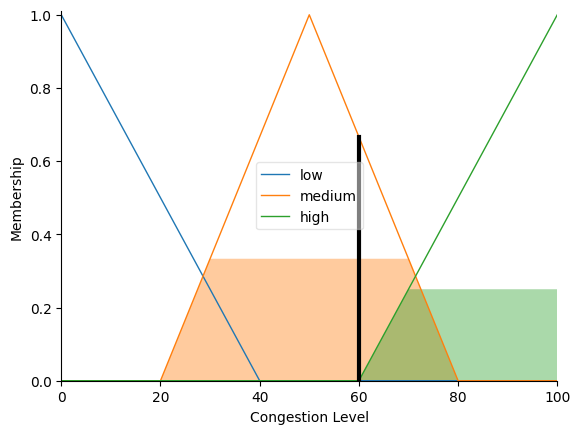

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# ======================
# Define Fuzzy Variables
# ======================

# Inputs
traffic_volume = ctrl.Antecedent(np.arange(0, 101, 1), 'Traffic Volume')   # 0 to 100
travel_time = ctrl.Antecedent(np.arange(0, 11, 1), 'Travel Time Index')   # 0 to 10

# Output
congestion = ctrl.Consequent(np.arange(0, 101, 1), 'Congestion Level')    # 0 to 100 scale

# ======================
# Membership Functions
# ======================

# Traffic Volume
traffic_volume['low'] = fuzz.trimf(traffic_volume.universe, [0, 0, 40])
traffic_volume['medium'] = fuzz.trimf(traffic_volume.universe, [20, 50, 80])
traffic_volume['high'] = fuzz.trimf(traffic_volume.universe, [60, 100, 100])

# Travel Time Index
travel_time['low'] = fuzz.trimf(travel_time.universe, [0, 0, 4])
travel_time['medium'] = fuzz.trimf(travel_time.universe, [2, 5, 8])
travel_time['high'] = fuzz.trimf(travel_time.universe, [6, 10, 10])

# Congestion Output
congestion['low'] = fuzz.trimf(congestion.universe, [0, 0, 40])
congestion['medium'] = fuzz.trimf(congestion.universe, [20, 50, 80])
congestion['high'] = fuzz.trimf(congestion.universe, [60, 100, 100])

# ======================
# Fuzzy Rules
# ======================
rule1 = ctrl.Rule(traffic_volume['low'] & travel_time['low'], congestion['low'])
rule2 = ctrl.Rule(traffic_volume['medium'] | travel_time['medium'], congestion['medium'])
rule3 = ctrl.Rule(traffic_volume['high'] & travel_time['high'], congestion['high'])

# Build system
congestion_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
congestion_sim = ctrl.ControlSystemSimulation(congestion_ctrl)

# ======================
# Example Predictions
# ======================
# Example input values
congestion_sim.input['Traffic Volume'] = 70
congestion_sim.input['Travel Time Index'] = 7

# Compute
congestion_sim.compute()
print("Predicted Congestion Level:", congestion_sim.output['Congestion Level'])

# ======================
# Visualization
# ======================
congestion.view(sim=congestion_sim)
plt.show()


Fuzzy Logic Accuracy: 88.03%

Confusion Matrix:
 [[ 338    0    0]
 [ 420 1189  650]
 [   0    0 6339]]

Classification Report:
               precision    recall  f1-score   support

         Low       0.45      1.00      0.62       338
      Medium       1.00      0.53      0.69      2259
        High       0.91      1.00      0.95      6339

    accuracy                           0.88      8936
   macro avg       0.78      0.84      0.75      8936
weighted avg       0.91      0.88      0.87      8936



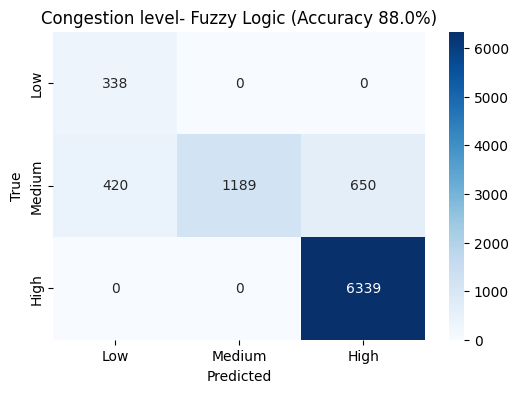

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# True labels (from dataset)
bins_true = [0, 30, 70, 100]
labels = ["Low", "Medium", "High"]
y_true = pd.cut(df["Congestion Level"], bins=bins_true, labels=labels, include_lowest=True).astype(str).tolist()

# -------------------------
# Fuzzy membership functions
# -------------------------
def low(x):
    if x <= 30:
        return 1
    elif 30 < x <= 50:
        return max(0, (50 - x) / 20)  # fades out
    else:
        return 0

def medium(x):
    if 30 < x <= 50:
        return (x - 30) / 20
    elif 50 < x <= 70:
        return (70 - x) / 20
    else:
        return 0

def high(x):
    if x >= 70:
        return 1
    elif 50 < x < 70:
        return (x - 50) / 20  # fades in
    else:
        return 0

# -------------------------
# Apply fuzzy logic
# -------------------------
y_pred = []
for val in df["Congestion Level"].values:
    memberships = {
        "Low": low(val),
        "Medium": medium(val),
        "High": high(val)
    }
    # Pick class with max membership
    y_pred.append(max(memberships, key=memberships.get))

# -------------------------
# Evaluate
# -------------------------
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred, labels=labels)

print(f"Fuzzy Logic Accuracy: {acc*100:.2f}%")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_true, y_pred, labels=labels))

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Congestion level- Fuzzy Logic (Accuracy {acc*100:.1f}%)")
plt.show()
